In [4]:
!pip install openpyxl
!pip install matplotlib
!pip install statsmodels
!pip install scipy





In [12]:
import pandas as pd

# === STEP 1: Load the Excel file ===
file_path = "/Users/ryanzeh/Desktop/Feature_Extraction/slim_features_umis_df_params20-12_cb_30-03-25_v1.2.xlsx" 
df = pd.read_excel(file_path)

# === STEP 2: Check number of unique patients ===
num_patients = df['PatientID'].nunique()
print(f"Unique patients: {num_patients}")

# === STEP 3: Count number of masks per patient ===
mask_counts = df['PatientID'].value_counts()
mask_counts_sorted = mask_counts.sort_index()
print("\nMasks per patient (sorted by Patient ID):")
print(mask_counts_sorted)

# === STEP 4: Calculate average number of masks per patient ===
avg_masks = mask_counts.mean()
print(f"\nAverage number of masks per patient: {avg_masks:.2f}")







Unique patients: 25

Masks per patient (sorted by Patient ID):
PatientID
LR_0001    2
LR_0002    7
LR_0004    5
LR_0010    2
LR_0011    4
LR_0013    5
LR_0015    3
LR_0020    4
LR_0021    2
LR_0023    6
LR_0027    6
LR_0028    9
LR_0029    5
LR_0033    6
LR_0036    5
LR_0037    4
LR_0038    4
LR_0039    3
LR_0040    3
LR_0042    5
LR_0046    7
LR_0048    6
LR_0049    3
LR_0050    2
LR_0051    6
Name: count, dtype: int64

Average number of masks per patient: 4.56


📊 Mean UMIS across 25 patients (each patient averaged first): 0.2370
🔺 Max UMIS across all masks: 0.2966
🔻 Min UMIS across all masks: 0.1143


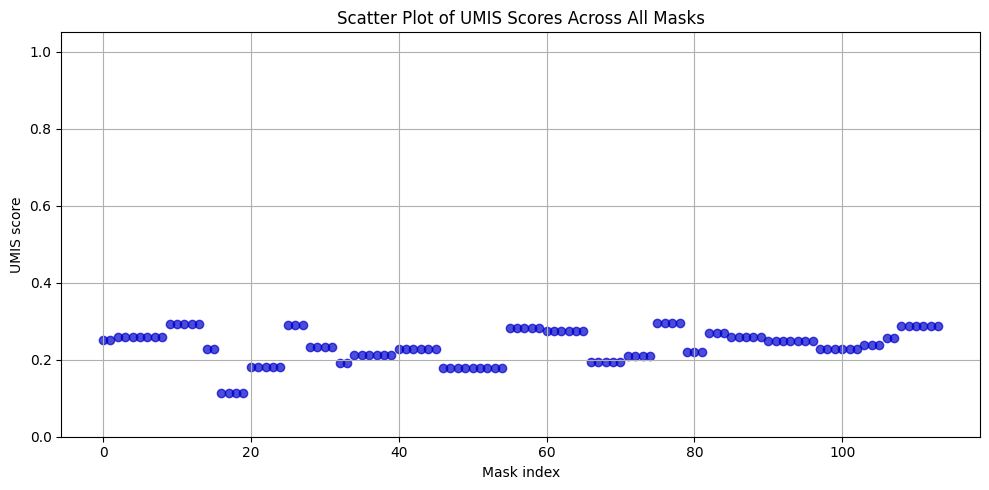

In [17]:
# === Step 1: Average UMIS per patient ===
umis_by_patient = df.groupby('PatientID')['UMIS'].mean()

# === Step 2: Mean of those 25 patient-level averages ===
mean_umis_across_patients = umis_by_patient.mean()
print(f"📊 Mean UMIS across 25 patients (each patient averaged first): {mean_umis_across_patients:.4f}")

# === Step 3: Print overall max and min UMIS (across all masks) ===
overall_max = df['UMIS'].max()
overall_min = df['UMIS'].min()
print(f"🔺 Max UMIS across all masks: {overall_max:.4f}")
print(f"🔻 Min UMIS across all masks: {overall_min:.4f}")


import matplotlib.pyplot as plt

# === Plot all UMIS scores ===
plt.figure(figsize=(10, 5))
plt.scatter(range(len(df)), df['UMIS'], alpha=0.7, color='mediumblue')
plt.xlabel("Mask index")
plt.ylabel("UMIS score")
plt.title("Scatter Plot of UMIS Scores Across All Masks")
plt.ylim(0, 1.05)  # since UMIS ranges from 0 to 1
plt.grid(True)
plt.tight_layout()
plt.show()



                            OLS Regression Results                            
Dep. Variable:                   UMIS   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.019
Method:                 Least Squares   F-statistic:                    0.1706
Date:                Mon, 31 Mar 2025   Prob (F-statistic):              0.843
Time:                        00:05:22   Log-Likelihood:                 152.96
No. Observations:                  89   AIC:                            -299.9
Df Residuals:                      86   BIC:                            -292.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

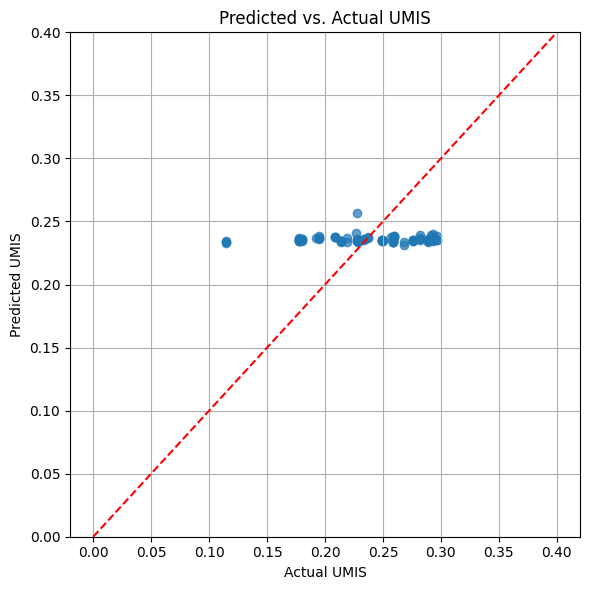

In [ ]:
##MULTIPLE REGRESSION 
##original_shape_VoxelVolume = number of voxels × voxel spacing
##and
##original_first_order_Mean = intensity mean

import statsmodels.api as sm

# === STEP 1: Filter your Data ===
df_filtered = df[df['mask_id'] != 1]

# === STEP 2: Define predictors and outcome ===
X = df_filtered[['original_shape_VoxelVolume', 'original_firstorder_Mean']]
y = df_filtered['UMIS']

# === STEP 3: Add constant (intercept) to X ===
X_with_const = sm.add_constant(X)

# === STEP 4: Fit OLS model ===
model = sm.OLS(y, X_with_const).fit()

# === STEP 5: View full summary (includes p-values) ===
print(model.summary())

# === STEP 6: Predict and plot ===
y_pred = model.predict(X_with_const)

plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, alpha=0.7)
plt.plot([0, 0.4], [0, 0.4], color='red', linestyle='--')
plt.xlabel("Actual UMIS")
plt.ylabel("Predicted UMIS")
plt.title("Predicted vs. Actual UMIS")
plt.ylim(0, 0.4)
plt.grid(True)
plt.tight_layout()
plt.show()


📊 Spearman Correlation Results
---------------------------------
Voxel Volume vs. UMIS:    r = 0.1210, p = 0.2882
Firstorder Mean vs. UMIS: r = -0.0426, p = 0.7094


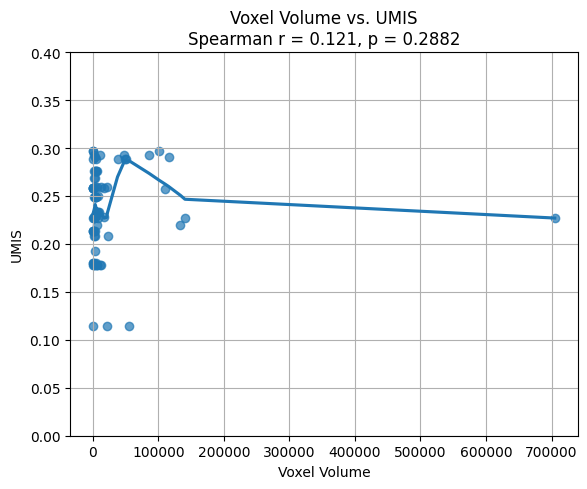

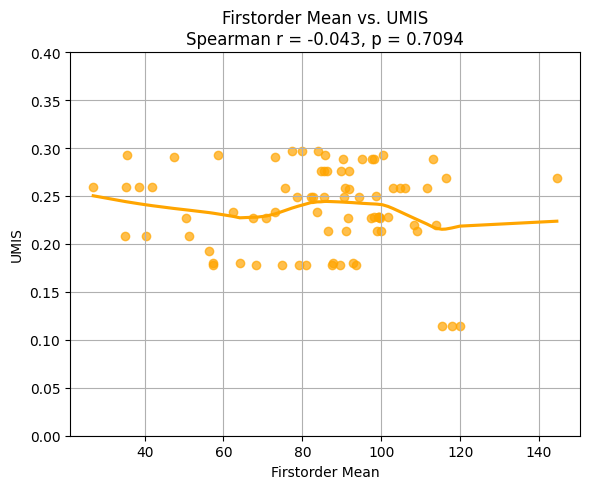

In [10]:
import pandas as pd
from scipy.stats import spearmanr


# Load your Excel file again
file_path = "/Users/ryanzeh/Desktop/Feature_Extraction/features_df_params20-12_cb_30-03-25_v1.2_slim_UMIS.xlsx"
df = pd.read_excel(file_path)


# === Filter out mask_id == 1 as before ===
df_filtered = df[df['mask_id'] != 1]

# === Extract relevant columns ===
voxel_volume = df_filtered['original_shape_VoxelVolume']
intensity_mean = df_filtered['original_firstorder_Mean']
umis = df_filtered['UMIS']

# === Compute Spearman correlations ===
corr_voxel, p_voxel = spearmanr(voxel_volume, umis)
corr_mean, p_mean = spearmanr(intensity_mean, umis)

print("📊 Spearman Correlation Results")
print("---------------------------------")
print(f"Voxel Volume vs. UMIS:    r = {corr_voxel:.4f}, p = {p_voxel:.4f}")
print(f"Firstorder Mean vs. UMIS: r = {corr_mean:.4f}, p = {p_mean:.4f}")


import matplotlib.pyplot as plt
!pip install seaborn
import seaborn as sns
from scipy.stats import spearmanr

# === Spearman 1: Voxel Volume vs. UMIS ===
corr_voxel, p_voxel = spearmanr(voxel_volume, umis)

plt.figure(figsize=(6, 5))
sns.regplot(x=voxel_volume, y=umis, lowess=True, scatter_kws={'alpha': 0.7})
plt.title(f"Voxel Volume vs. UMIS\nSpearman r = {corr_voxel:.3f}, p = {p_voxel:.4f}")
plt.xlabel("Voxel Volume")
plt.ylabel("UMIS")
plt.ylim(0, 0.4)
plt.grid(True)
plt.tight_layout()
plt.show()

# === Spearman 2: Firstorder Mean vs. UMIS ===
corr_mean, p_mean = spearmanr(intensity_mean, umis)

plt.figure(figsize=(6, 5))
sns.regplot(x=intensity_mean, y=umis, lowess=True, scatter_kws={'alpha': 0.7}, color='orange')
plt.title(f"Firstorder Mean vs. UMIS\nSpearman r = {corr_mean:.3f}, p = {p_mean:.4f}")
plt.xlabel("Firstorder Mean")
plt.ylabel("UMIS")
plt.ylim(0, 0.4)
plt.grid(True)
plt.tight_layout()
plt.show()



